# Limpieza, análisis de importancia y selección final de variables

Este notebook toma como punto de partida el dataset final unido a nivel cliente (`SK_ID_CURR`) y realiza una etapa completa de depuración y selección de columnas para entrenamiento.

El flujo está diseñado para el proyecto de riesgo crediticio de Home Credit:

1. Carga `final_train_features.parquet` o lo construye usando `build_final_train_dataset.py`.
2. Valida que exista una sola fila por cliente.
3. Analiza cada columna: nulos, cardinalidad, constantes, valores dominantes, outliers y tipo de dato.
4. Aplica reglas básicas de limpieza.
5. Evalúa relación con `TARGET` usando correlación, información mutua e importancia por permutación.
6. Elimina columnas redundantes por alta correlación entre variables.
7. Exporta un dataset final con únicamente las columnas recomendadas para modelado.

> La idea no es borrar columnas a ciegas. Cada decisión queda documentada en reportes para poder justificar qué se conserva y qué se elimina.

## 1. Configuración general

Ajusta estas rutas si tu proyecto usa otra estructura. Por defecto se espera una carpeta `data/` con los archivos `.parquet` o `.csv` del proyecto.

In [4]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"

# Si ejecutas el notebook desde otra carpeta, ajusta manualmente:
# DATA_DIR = Path("/ruta/a/tu/proyecto/data")

FINAL_DATASET_PATH = DATA_DIR / "trusted/joined_df.parquet"
SELECTED_DATASET_PATH = DATA_DIR / "train_selected_features_2.parquet"
REPORTS_DIR = DATA_DIR / "feature_selection_reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

ID_COL = "SK_ID_CURR"
TARGET_COL = "TARGET"
RANDOM_STATE = 42

# Umbrales de limpieza y selección.
HIGH_NULL_THRESHOLD = 0.80
NEAR_CONSTANT_THRESHOLD = 0.90
HIGH_CARDINALITY_THRESHOLD = 80
OUTLIER_IQR_THRESHOLD = 0.15
CORR_WITH_TARGET_MIN = 0.003
MI_MIN = 0.0001
PERM_IMPORTANCE_MIN = 0.0000
PREDICTOR_CORR_THRESHOLD = 0.90

# Para acelerar el análisis por permutación.
PERMUTATION_VALID_SAMPLE = 20000
PERMUTATION_REPEATS = 5

## 2. Carga del dataset final

Este notebook espera que ya exista el dataset unido final. Si no existe, intenta construirlo automáticamente usando el script `build_final_train_dataset.py` generado previamente.

La tabla final debe tener:

- `SK_ID_CURR`: identificador único del cliente.
- `TARGET`: variable objetivo.
- Una fila por cliente.
- Features agregadas desde las tablas históricas.

In [5]:
def find_data_dir(start: Path = Path.cwd()) -> Path:
    """Busca una carpeta data/ desde el directorio actual o sus padres."""
    for base in [start, *start.parents]:
        candidates = [base / "data", base / "Proyecto_Integrador" / "data"]
        for candidate in candidates:
            if candidate.exists():
                return candidate
    raise FileNotFoundError("No se encontró carpeta data/. Ajusta DATA_DIR manualmente.")

if not DATA_DIR.exists():
    DATA_DIR = find_data_dir(PROJECT_DIR)
    FINAL_DATASET_PATH = DATA_DIR / "final_train_features.parquet"
    SELECTED_DATASET_PATH = DATA_DIR / "train_selected_features_2.parquet"
    REPORTS_DIR = DATA_DIR / "feature_selection_reports"
    REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"DATA_DIR: {DATA_DIR}")
print(f"Dataset final esperado: {FINAL_DATASET_PATH}")

DATA_DIR: /workspaces/Proyecto_Integrador/data
Dataset final esperado: /workspaces/Proyecto_Integrador/data/trusted/joined_df.parquet


In [6]:
if FINAL_DATASET_PATH.exists():
    df = pd.read_parquet(FINAL_DATASET_PATH)
    print(f"[OK] Dataset cargado: {FINAL_DATASET_PATH}")
else:
    print(f"[ERROR] No se encontró el dataset final en {FINAL_DATASET_PATH}. Asegúrate de ejecutar los scripts previos para generar este archivo.")

print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]:,}")
display(df.head())

[OK] Dataset cargado: /workspaces/Proyecto_Integrador/data/trusted/joined_df.parquet
Filas: 307,511
Columnas: 137


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_3,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_8,FLAG_DOCUMENT_16,FLAG_DOCUMENT_18,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,DAYS_EMPLOYED_FLAG,AGE_YEARS,YEARS_EMPLOYED,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_GOODS_RATIO,INCOME_PER_PERSON,EXT_SOURCE_MEAN,EXT_SOURCE_MIN,BUREAU_QUERIES_TOTAL,bureau_n_credits,bureau_n_active,bureau_n_closed,bureau_n_bad,bureau_avg_days_credit,bureau_min_days_credit,bureau_avg_days_update,bureau_max_overdue_days,bureau_sum_overdue_days,bureau_total_credit,bureau_total_debt,bureau_total_overdue_amt,bureau_n_prolonged,bureau_n_consumer,bureau_n_card,bureau_n_mortgage,bureau_n_car_loan,bureau_active_pct,bureau_closed_pct,bureau_has_bad_debt,bureau_has_overdue,bureau_debt_ratio,bureau_mean_credit_duration,bureau_mean_days_overrun,bureau_pct_paid_early,no_bureau_history,prev_app_count,prev_approved_rate,prev_refused_rate,prev_canceled_rate,prev_unused_offer_rate,prev_contract_type_cash_rate,prev_contract_type_consumer_rate,prev_contract_type_revolving_rate,prev_annuity_approved_mean,prev_annuity_approved_max,prev_application_mean,prev_application_max,prev_credit_approved_mean,prev_credit_application_ratio_mean,prev_goods_price_mean,prev_goods_price_max,prev_cnt_payment_mean,prev_cnt_payment_max,prev_reject_hc_rate,prev_reject_limit_rate,prev_reject_sco_rate,prev_yield_high_rate,prev_yield_low_rate,prev_insured_on_approval_rate,prev_insured_on_approval_count,no_previous_application_history
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-637.0,-3648.0,-2120,0.0,1,0,1,0,Laborers,1.0,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,-1134.0,1,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0,25.902806,1.744011,2.007889,0.121978,1.158397,202500.0,0.161787,0.083037,1.0,8.0,2.0,6.0,0.0,-874.00,-1437.0,-499.875,0.0,0.0,865055.565,245781.0,0.0,0.0,4.0,4.0,0.0,0.0,0.25,0.75,0.0,0.0,0.284121,277.000000,-163.5,0.166667,0,1.0,1.000000,0.000000,0.000000,0.0,0.000000,1.000000,0.000000,9251.775,9251.775,179055.00,179055.0,179055.00,1.000000,179055.00,179055.0,24.000000,24.0,0.0,0.0,0.0,0.000000,1.000000,0.000000,0.0,0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-1188.0,-1186.0,-291,0.0,1,0,1,0,Core staff,2.0,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,0.535276,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,reg oper account,block of flats,0.071

## 3. Validaciones iniciales

Antes de limpiar columnas se valida que la tabla tenga la estructura correcta para entrenamiento:

- `SK_ID_CURR` debe existir.
- `TARGET` debe existir.
- No debe haber clientes duplicados.
- `TARGET` debe ser binario o, al menos, tener pocos valores esperados.

In [7]:
required_cols = [ID_COL, TARGET_COL]
missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise ValueError(f"Faltan columnas obligatorias: {missing_required}")

n_duplicated_ids = df[ID_COL].duplicated().sum()
print(f"Clientes duplicados por {ID_COL}: {n_duplicated_ids:,}")

if n_duplicated_ids > 0:
    print("Se conserva el primer registro por cliente para evitar duplicados en entrenamiento.")
    df = df.drop_duplicates(subset=[ID_COL], keep="first").copy()

target_distribution = df[TARGET_COL].value_counts(dropna=False).to_frame("count")
target_distribution["pct"] = target_distribution["count"] / len(df)
display(target_distribution)

if df[TARGET_COL].isna().any():
    raise ValueError("TARGET contiene nulos. Revisa application_train antes de entrenar.")

Clientes duplicados por SK_ID_CURR: 0


,count,pct
TARGET,,
0,282686,0.919271
1,24825,0.080729


## 4. Perfil columna por columna

Esta sección calcula métricas para justificar decisiones de limpieza:

- **% nulos:** columnas con demasiados nulos suelen aportar poca estabilidad.
- **Cardinalidad:** variables categóricas con muchas categorías pueden generar ruido o demasiadas columnas dummy.
- **Valor dominante:** si casi todos los registros tienen el mismo valor, la columna tiene poca información.
- **Outliers:** se detectan con la regla IQR. No necesariamente se eliminan; muchas veces se recortan con percentiles.
- **Correlación con `TARGET`:** útil para variables numéricas, aunque en riesgo crediticio muchas señales son débiles individualmente.

In [8]:
def outlier_iqr_pct(series: pd.Series) -> float:
    """Calcula porcentaje de outliers usando regla IQR para una columna numérica."""
    x = pd.to_numeric(series, errors="coerce").dropna()
    if len(x) < 10:
        return np.nan
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0 or pd.isna(iqr):
        return 0.0
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return ((x < lower) | (x > upper)).mean()


def compute_column_profile(data: pd.DataFrame, target_col: str = TARGET_COL) -> pd.DataFrame:
    rows = []
    y = data[target_col] if target_col in data.columns else None

    for col in data.columns:
        s = data[col]
        non_null = s.dropna()
        null_count = s.isna().sum()
        null_pct = null_count / len(data)
        nunique = s.nunique(dropna=True)
        nunique_including_null = s.nunique(dropna=False)
        dominant_pct = s.value_counts(dropna=False, normalize=True).iloc[0] if len(non_null) > 0 else 1.0

        is_numeric = pd.api.types.is_numeric_dtype(s)
        outlier_pct = outlier_iqr_pct(s) if is_numeric and col not in [target_col, ID_COL] else np.nan
        zero_pct = s.eq(0).mean() if is_numeric else np.nan
        skew = pd.to_numeric(s, errors="coerce").skew() if is_numeric and col not in [target_col, ID_COL] else np.nan

        corr_target = np.nan
        if y is not None and is_numeric and col not in [target_col, ID_COL]:
            valid = s.notna() & y.notna()
            if valid.sum() > 10 and s[valid].nunique() > 1:
                corr_target = s[valid].corr(y[valid])

        rows.append({
            "column": col,
            "dtype": str(s.dtype),
            "is_numeric": is_numeric,
            "null_count": null_count,
            "null_pct": null_pct,
            "nunique": nunique,
            "nunique_including_null": nunique_including_null,
            "dominant_pct": dominant_pct,
            "zero_pct": zero_pct,
            "outlier_iqr_pct": outlier_pct,
            "skew": skew,
            "corr_with_target": corr_target,
            "abs_corr_with_target": abs(corr_target) if pd.notna(corr_target) else np.nan,
        })

    return pd.DataFrame(rows).sort_values(
        ["null_pct", "dominant_pct", "abs_corr_with_target"],
        ascending=[False, False, False]
    )

profile = compute_column_profile(df)
profile.to_csv(REPORTS_DIR / "01_column_profile_raw.csv", index=False)

display(profile.head(30))
print("Reporte guardado en:", REPORTS_DIR / "01_column_profile_raw.csv")

,column,dtype,is_numeric,null_count,null_pct,nunique,nunique_including_null,dominant_pct,zero_pct,outlier_iqr_pct,skew,corr_with_target,abs_corr_with_target
70,AMT_REQ_CREDIT_BUREAU_DAY,float64,True,0,0.0,9,9,0.995158,0.995158,0.0,29.081577,0.001701,0.001701
69,AMT_REQ_CREDIT_BUREAU_HOUR,float64,True,0,0.0,5,5,0.994712,0.994712,0.0,15.641990,-0.000074,0.000074
68,FLAG_DOCUMENT_18,int64,True,0,0.0,2,2,0.991870,0.991870,0.0,10.955080,-0.007952,0.007952
67,FLAG_DOCUMENT_16,int64,True,0,0.0,2,2,0.990072,0.990072,0.0,9.886111,-0.011615,0.011615
96,bureau_total_overdue_amt,float64,True,0,0.0,1218,1218,0.989158,0.989158,0.0,164.832764,0.011943,0.011943
105,bureau_has_overdue,float64,True,0,0.0,2,2,0.988953,0.988953,0.0,9.356084,0.030352,0.030352
93,bureau_sum_overdue_days,float64,True,0,0.0,879,879,0.988953,0.988953,0.0,25.506577,0.005092,0.005092
92,bureau_max_overdue_days,float64,True,0,0.0,868,868,0.988953,0.988953,0.0,24.899235,0.004360,0.004360
64,FLAG_DOCUMENT_5,int64,True,0,0.0,2,2,0.984885,0.984885,0.0,7.948322,-0.000316,0.000316
30,REG_REGION_NOT_LIVE_REGION,int64,True,0,0.0,2,2,0.984856,0.984856,0.0,7.940276,0.005576,0.005576


Reporte guardado en: /workspaces/Proyecto_Integrador/data/feature_selection_reports/01_column_profile_raw.csv


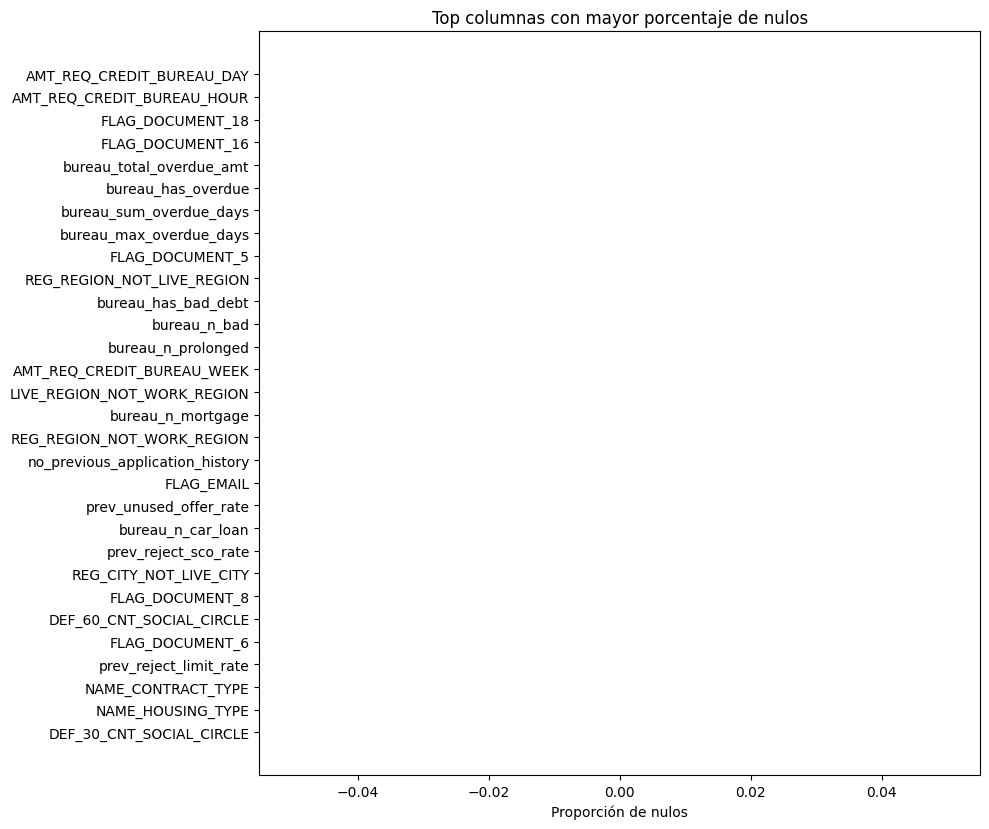

In [9]:
plot_nulls = profile[(profile["column"] != TARGET_COL) & (profile["column"] != ID_COL)].copy()
plot_nulls = plot_nulls.sort_values("null_pct", ascending=False).head(30)

plt.figure(figsize=(10, max(4, len(plot_nulls) * 0.28)))
plt.barh(plot_nulls["column"][::-1], plot_nulls["null_pct"][::-1])
plt.xlabel("Proporción de nulos")
plt.title("Top columnas con mayor porcentaje de nulos")
plt.tight_layout()
plt.show()

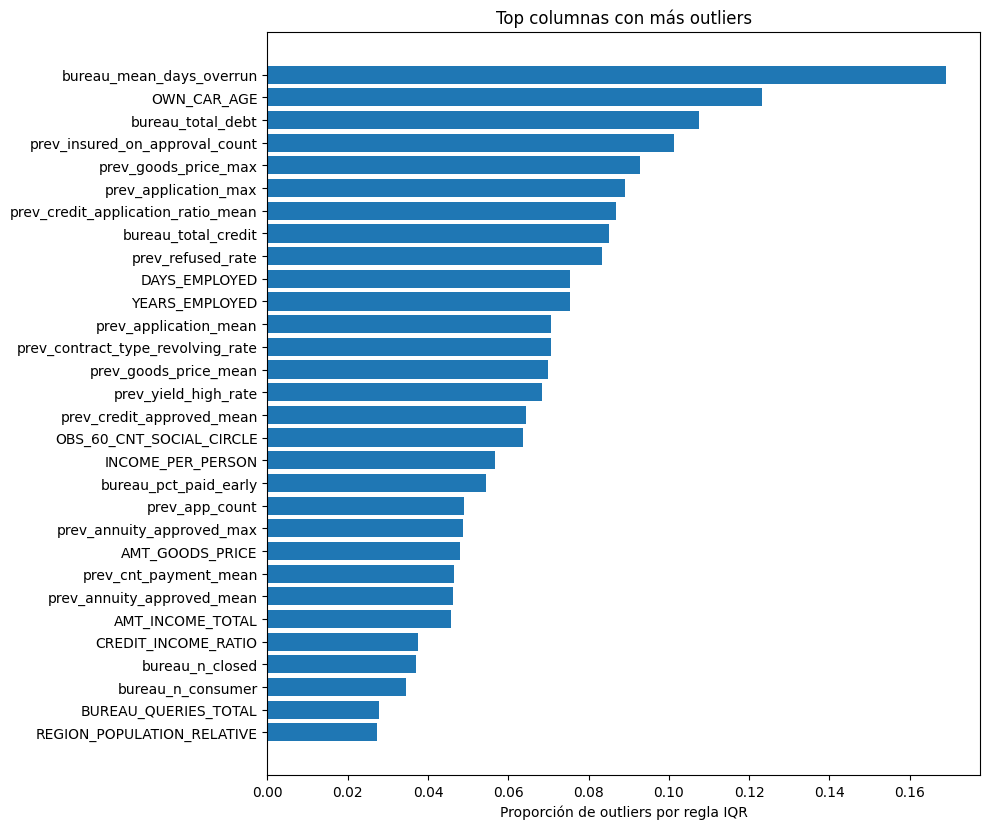

In [10]:
plot_outliers = profile.dropna(subset=["outlier_iqr_pct"]).copy()
plot_outliers = plot_outliers.sort_values("outlier_iqr_pct", ascending=False).head(30)

plt.figure(figsize=(10, max(4, len(plot_outliers) * 0.28)))
plt.barh(plot_outliers["column"][::-1], plot_outliers["outlier_iqr_pct"][::-1])
plt.xlabel("Proporción de outliers por regla IQR")
plt.title("Top columnas con más outliers")
plt.tight_layout()
plt.show()

## 5. Reglas básicas de limpieza por columna

Las reglas aplicadas son conservadoras para no perder señales útiles:

1. **Eliminar identificadores técnicos:** `SK_ID_CURR` no se usa como predictor.
2. **Eliminar columnas completamente nulas.**
3. **Eliminar columnas con nulos extremos:** por defecto, `>=90%` de nulos.
4. **Eliminar constantes o casi constantes:** si un valor domina `>=99.5%`.
5. **Tratar infinitos como nulos.**
6. **Imputar numéricas con mediana.**
7. **Imputar categóricas con `Unknown`.**
8. **Crear indicadores de nulo** para columnas donde la ausencia puede ser informativa.
9. **Recortar outliers numéricos con percentiles 1 y 99**, ajustando límites solo con train para evitar leakage.

> Los outliers no se eliminan por fila porque en crédito pueden representar clientes reales de alto riesgo. Se recortan para estabilizar modelos sensibles a escala.

In [11]:
decisions = []

def add_decision(column, action, reason):
    decisions.append({"column": column, "action": action, "reason": reason})

protected_cols = {TARGET_COL}
initial_drop_cols = {ID_COL}

for col in initial_drop_cols:
    if col in df.columns:
        add_decision(col, "drop", "Identificador técnico; no debe usarse como predictor.")

all_null_cols = profile.loc[
    (profile["null_pct"] >= 1.0) & (~profile["column"].isin(protected_cols)),
    "column"
].tolist()
for col in all_null_cols:
    add_decision(col, "drop", "Columna completamente nula.")

high_null_cols = profile.loc[
    (profile["null_pct"] >= HIGH_NULL_THRESHOLD)
    & (~profile["column"].isin(protected_cols | initial_drop_cols))
    & (~profile["column"].isin(all_null_cols)),
    "column"
].tolist()
for col in high_null_cols:
    add_decision(col, "drop", f"Tiene >= {HIGH_NULL_THRESHOLD:.0%} de nulos; baja estabilidad para entrenamiento.")

constant_cols = profile.loc[
    (profile["nunique_including_null"] <= 1)
    & (~profile["column"].isin(protected_cols | initial_drop_cols)),
    "column"
].tolist()
for col in constant_cols:
    add_decision(col, "drop", "Columna constante; no aporta separación entre clientes.")

near_constant_cols = profile.loc[
    (profile["dominant_pct"] >= NEAR_CONSTANT_THRESHOLD)
    & (~profile["column"].isin(protected_cols | initial_drop_cols))
    & (~profile["column"].isin(constant_cols))
    & (~profile["column"].isin(all_null_cols))
    & (~profile["column"].isin(high_null_cols)),
    "column"
].tolist()
for col in near_constant_cols:
    add_decision(col, "drop", f"Casi constante: un valor domina >= {NEAR_CONSTANT_THRESHOLD:.1%}.")

quality_drop_cols = sorted(set(initial_drop_cols) | set(all_null_cols) | set(high_null_cols) | set(constant_cols) | set(near_constant_cols))

clean_base = df.drop(columns=[c for c in quality_drop_cols if c in df.columns], errors="ignore").copy()
clean_base = clean_base.replace([np.inf, -np.inf], np.nan)

print(f"Columnas iniciales: {df.shape[1]:,}")
print(f"Columnas eliminadas por reglas básicas: {len(quality_drop_cols):,}")
print(f"Columnas después de limpieza básica: {clean_base.shape[1]:,}")

quality_decisions = pd.DataFrame(decisions)
quality_decisions.to_csv(REPORTS_DIR / "02_basic_cleaning_decisions.csv", index=False)
display(quality_decisions.head(100))
print("Reporte guardado en:", REPORTS_DIR / "02_basic_cleaning_decisions.csv")

Columnas iniciales: 137
Columnas eliminadas por reglas básicas: 29
Columnas después de limpieza básica: 108


,column,action,reason
0,SK_ID_CURR,drop,Identificador técnico; no debe usarse como pre...
1,AMT_REQ_CREDIT_BUREAU_DAY,drop,Casi constante: un valor domina >= 90.0%.
2,AMT_REQ_CREDIT_BUREAU_HOUR,drop,Casi constante: un valor domina >= 90.0%.
3,FLAG_DOCUMENT_18,drop,Casi constante: un valor domina >= 90.0%.
4,FLAG_DOCUMENT_16,drop,Casi constante: un valor domina >= 90.0%.
5,bureau_total_overdue_amt,drop,Casi constante: un valor domina >= 90.0%.
6,bureau_has_overdue,drop,Casi constante: un valor domina >= 90.0%.
7,bureau_sum_overdue_days,drop,Casi constante: un valor domina >= 90.0%.
8,bureau_max_overdue_days,drop,Casi constante: un valor domina >= 90.0%.
9,FLAG_DOCUMENT_5,drop,Casi constante: un valor domina >= 90.0%.


Reporte guardado en: /workspaces/Proyecto_Integrador/data/feature_selection_reports/02_basic_cleaning_decisions.csv


## 6. Separación train/valid para evitar leakage

La imputación, el recorte de outliers y el análisis de importancia se ajustan usando la muestra de entrenamiento. Esto evita que estadísticas de validación influyan en las decisiones.

In [12]:
X = clean_base.drop(columns=[TARGET_COL])
y = clean_base[TARGET_COL].astype(int)

X_train_raw, X_valid_raw, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"X_train_raw: {X_train_raw.shape}")
print(f"X_valid_raw: {X_valid_raw.shape}")
print(f"Target rate train: {y_train.mean():.4f}")
print(f"Target rate valid: {y_valid.mean():.4f}")

X_train_raw: (246008, 107)
X_valid_raw: (61503, 107)
Target rate train: 0.0807
Target rate valid: 0.0807


## 7. Indicadores de nulo y tratamiento de outliers

Se crean flags `*_was_missing` para columnas con nulos porque en crédito la ausencia de información puede ser predictiva. Luego se recortan outliers numéricos usando límites P1-P99 aprendidos solo en `train`.

In [13]:
def add_missing_indicators(train_df: pd.DataFrame, valid_df: pd.DataFrame, min_missing_pct: float = 0.001):
    train_out = train_df.copy()
    valid_out = valid_df.copy()
    missing_cols = train_out.columns[train_out.isna().mean() >= min_missing_pct].tolist()

    for col in missing_cols:
        flag_col = f"{col}_was_missing"
        train_out[flag_col] = train_out[col].isna().astype(int)
        valid_out[flag_col] = valid_out[col].isna().astype(int) if col in valid_out.columns else 0

    return train_out, valid_out, missing_cols


def fit_winsor_limits(train_df: pd.DataFrame, numeric_cols, lower_q=0.01, upper_q=0.99):
    limits = {}
    for col in numeric_cols:
        s = pd.to_numeric(train_df[col], errors="coerce")
        if s.notna().sum() < 10:
            continue
        lower = s.quantile(lower_q)
        upper = s.quantile(upper_q)
        if pd.notna(lower) and pd.notna(upper) and lower < upper:
            limits[col] = (lower, upper)
    return limits


def apply_winsor_limits(data: pd.DataFrame, limits: dict):
    out = data.copy()
    for col, (lower, upper) in limits.items():
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce").clip(lower, upper)
    return out

X_train_miss, X_valid_miss, missing_indicator_source_cols = add_missing_indicators(X_train_raw, X_valid_raw)

numeric_cols_before = X_train_miss.select_dtypes(include=[np.number, "bool"]).columns.tolist()
winsor_limits = fit_winsor_limits(X_train_miss, numeric_cols_before)

X_train_clean = apply_winsor_limits(X_train_miss, winsor_limits)
X_valid_clean = apply_winsor_limits(X_valid_miss, winsor_limits)

print(f"Columnas con indicador de nulo creado: {len(missing_indicator_source_cols):,}")
print(f"Columnas numéricas con límites de outliers P1-P99: {len(winsor_limits):,}")

Columnas con indicador de nulo creado: 0
Columnas numéricas con límites de outliers P1-P99: 92


## 8. Correlación de variables numéricas con `TARGET`

La correlación ayuda a detectar señales lineales simples. Sin embargo, no se debe seleccionar únicamente por correlación porque muchas variables pueden aportar de forma no lineal o en interacción con otras.

In [14]:
numeric_cols = X_train_clean.select_dtypes(include=[np.number, "bool"]).columns.tolist()

corr_rows = []
for col in numeric_cols:
    s = pd.to_numeric(X_train_clean[col], errors="coerce")
    valid = s.notna() & y_train.notna()
    if valid.sum() > 20 and s[valid].nunique() > 1:
        pearson_corr = s[valid].corr(y_train[valid], method="pearson")
        spearman_corr = s[valid].corr(y_train[valid], method="spearman")
    else:
        pearson_corr = np.nan
        spearman_corr = np.nan

    corr_rows.append({
        "column": col,
        "pearson_corr_target": pearson_corr,
        "spearman_corr_target": spearman_corr,
        "abs_pearson_corr_target": abs(pearson_corr) if pd.notna(pearson_corr) else np.nan,
        "abs_spearman_corr_target": abs(spearman_corr) if pd.notna(spearman_corr) else np.nan,
    })

corr_target = pd.DataFrame(corr_rows).sort_values("abs_pearson_corr_target", ascending=False)
corr_target.to_csv(REPORTS_DIR / "03_numeric_correlation_with_target.csv", index=False)

display(corr_target.head(30))
print("Reporte guardado en:", REPORTS_DIR / "03_numeric_correlation_with_target.csv")

,column,pearson_corr_target,spearman_corr_target,abs_pearson_corr_target,abs_spearman_corr_target
50,EXT_SOURCE_MEAN,-0.218985,-0.204739,0.218985,0.204739
51,EXT_SOURCE_MIN,-0.192573,-0.181129,0.192573,0.181129
19,EXT_SOURCE_2,-0.159091,-0.146321,0.159091,0.146321
20,EXT_SOURCE_3,-0.155691,-0.141933,0.155691,0.141933
18,EXT_SOURCE_1,-0.097954,-0.085904,0.097954,0.085904
56,bureau_avg_days_credit,0.083391,0.086334,0.083391,0.086334
44,AGE_YEARS,-0.079451,-0.079573,0.079451,0.079573
72,prev_refused_rate,0.078679,0.068932,0.078679,0.068932
64,bureau_closed_pct,-0.076033,-0.077322,0.076033,0.077322
58,bureau_avg_days_update,0.073095,0.076891,0.073095,0.076891


Reporte guardado en: /workspaces/Proyecto_Integrador/data/feature_selection_reports/03_numeric_correlation_with_target.csv


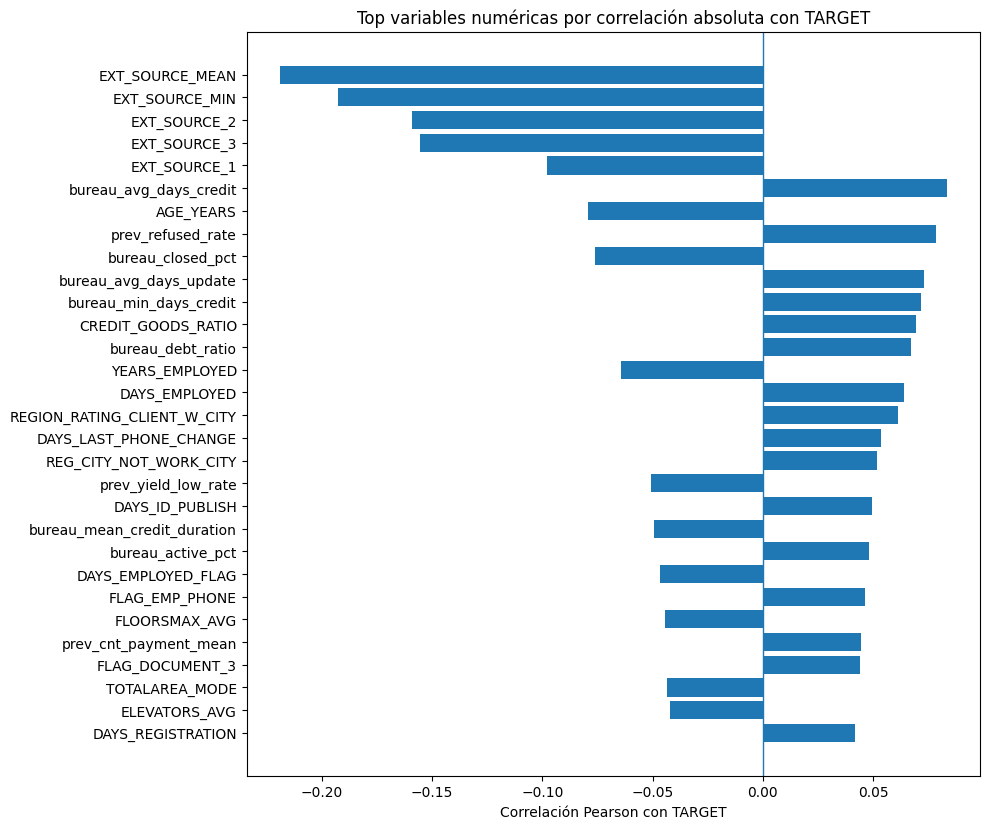

In [15]:
plot_corr = corr_target.dropna(subset=["pearson_corr_target"]).head(30).copy()

plt.figure(figsize=(10, max(4, len(plot_corr) * 0.28)))
plt.barh(plot_corr["column"][::-1], plot_corr["pearson_corr_target"][::-1])
plt.axvline(0, linewidth=1)
plt.xlabel("Correlación Pearson con TARGET")
plt.title("Top variables numéricas por correlación absoluta con TARGET")
plt.tight_layout()
plt.show()

## 9. Información mutua con `TARGET`

La información mutua detecta relaciones no necesariamente lineales. Para calcularla, las categóricas se codifican ordinalmente solo para este análisis. No significa que el modelo final use ordinalidad real.

In [16]:
def prepare_for_mutual_info(X_df: pd.DataFrame):
    X_temp = X_df.copy()
    num_cols = X_temp.select_dtypes(include=[np.number, "bool"]).columns.tolist()
    cat_cols = [c for c in X_temp.columns if c not in num_cols]

    for col in num_cols:
        median = X_temp[col].median()
        X_temp[col] = X_temp[col].fillna(median)

    if cat_cols:
        X_temp[cat_cols] = X_temp[cat_cols].astype("object").fillna("Unknown")
        encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
        X_temp[cat_cols] = encoder.fit_transform(X_temp[cat_cols])

    discrete_mask = [col in cat_cols or X_temp[col].nunique() <= 20 for col in X_temp.columns]
    return X_temp, discrete_mask

X_mi, discrete_mask = prepare_for_mutual_info(X_train_clean)

mi_values = mutual_info_classif(
    X_mi,
    y_train,
    discrete_features=discrete_mask,
    random_state=RANDOM_STATE,
)

mi_report = (
    pd.DataFrame({"column": X_mi.columns, "mutual_info_target": mi_values})
    .sort_values("mutual_info_target", ascending=False)
)
mi_report.to_csv(REPORTS_DIR / "04_mutual_information_with_target.csv", index=False)

display(mi_report.head(40))
print("Reporte guardado en:", REPORTS_DIR / "04_mutual_information_with_target.csv")

,column,mutual_info_target
36,COMMONAREA_AVG,0.044945
44,NONLIVINGAPARTMENTS_AVG,0.044149
35,YEARS_BUILD_AVG,0.027865
40,FLOORSMIN_AVG,0.025126
65,EXT_SOURCE_MEAN,0.023599
42,LIVINGAPARTMENTS_AVG,0.022584
66,EXT_SOURCE_MIN,0.021553
33,BASEMENTAREA_AVG,0.020190
45,NONLIVINGAREA_AVG,0.020161
39,FLOORSMAX_AVG,0.020094


Reporte guardado en: /workspaces/Proyecto_Integrador/data/feature_selection_reports/04_mutual_information_with_target.csv


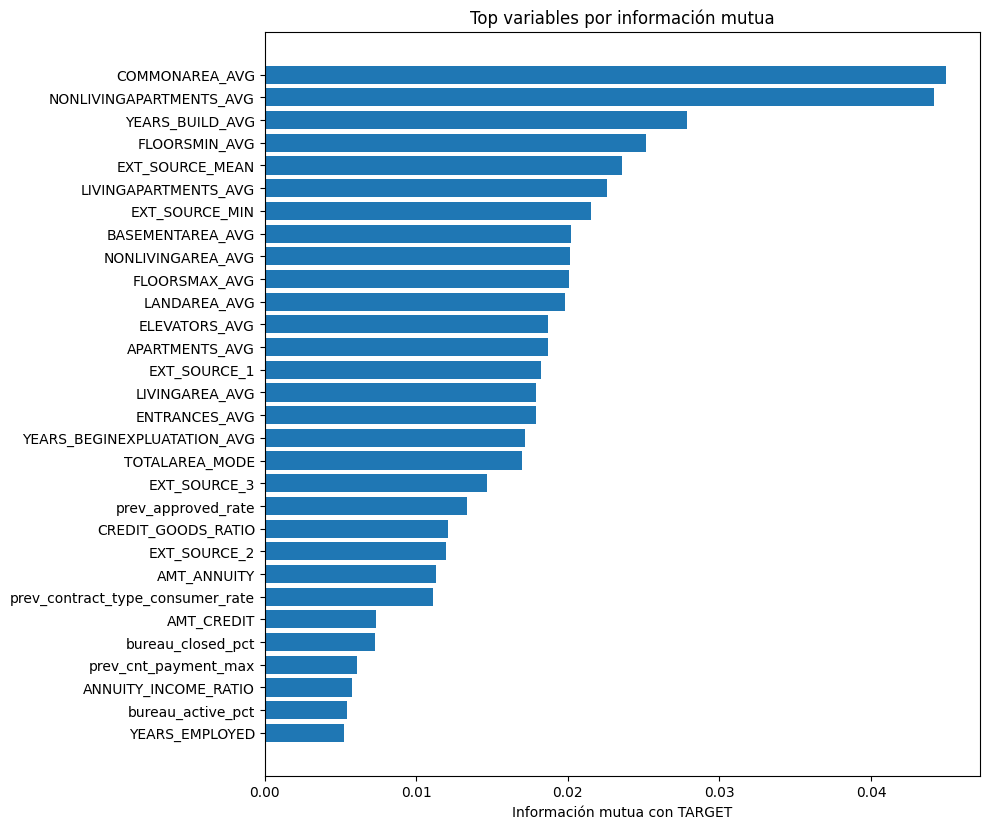

In [17]:
plot_mi = mi_report.head(30).copy()

plt.figure(figsize=(10, max(4, len(plot_mi) * 0.28)))
plt.barh(plot_mi["column"][::-1], plot_mi["mutual_info_target"][::-1])
plt.xlabel("Información mutua con TARGET")
plt.title("Top variables por información mutua")
plt.tight_layout()
plt.show()

## 10. Modelo base e importancia por permutación

Se entrena un modelo base con `RandomForestClassifier` para obtener importancia por permutación sobre validación. Esta métrica es más cercana a la utilidad real de cada columna porque mide cuánto baja el AUC cuando se desordena una variable.

No es el modelo final obligatorio; es una herramienta de selección de variables.

In [18]:
numeric_features = X_train_clean.select_dtypes(include=[np.number, "bool"]).columns.tolist()
categorical_features = [c for c in X_train_clean.columns if c not in numeric_features]

print(f"Features numéricas: {len(numeric_features):,}")
print(f"Features categóricas: {len(categorical_features):,}")

try:
    ohe = OneHotEncoder(handle_unknown="ignore", min_frequency=0.01, sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", min_frequency=0.01, sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_features),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
            ("onehot", ohe),
        ]), categorical_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

base_model = RandomForestClassifier(
    n_estimators=250,
    max_depth=8,
    min_samples_leaf=50,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

model_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", base_model),
])

model_pipeline.fit(X_train_clean, y_train)
valid_pred = model_pipeline.predict_proba(X_valid_clean)[:, 1]
valid_auc = roc_auc_score(y_valid, valid_pred)
print(f"AUC validación modelo base: {valid_auc:.4f}")

Features numéricas: 92
Features categóricas: 15


AUC validación modelo base: 0.7519


In [19]:
if len(X_valid_clean) > PERMUTATION_VALID_SAMPLE:
    valid_sample_idx = X_valid_clean.sample(PERMUTATION_VALID_SAMPLE, random_state=RANDOM_STATE).index
    X_perm = X_valid_clean.loc[valid_sample_idx]
    y_perm = y_valid.loc[valid_sample_idx]
else:
    X_perm = X_valid_clean
    y_perm = y_valid

perm_result = permutation_importance(
    model_pipeline,
    X_perm,
    y_perm,
    scoring="roc_auc",
    n_repeats=PERMUTATION_REPEATS,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

perm_report = pd.DataFrame({
    "column": X_perm.columns,
    "perm_importance_mean": perm_result.importances_mean,
    "perm_importance_std": perm_result.importances_std,
}).sort_values("perm_importance_mean", ascending=False)

perm_report.to_csv(REPORTS_DIR / "05_permutation_importance.csv", index=False)
display(perm_report.head(40))
print("Reporte guardado en:", REPORTS_DIR / "05_permutation_importance.csv")

,column,perm_importance_mean,perm_importance_std
65,EXT_SOURCE_MEAN,0.017371,0.002221
66,EXT_SOURCE_MIN,0.006204,0.001375
31,EXT_SOURCE_3,0.005467,0.001034
30,EXT_SOURCE_2,0.005260,0.001094
10,NAME_EDUCATION_TYPE,0.004707,0.000424
63,CREDIT_GOODS_RATIO,0.002630,0.000208
29,EXT_SOURCE_1,0.002139,0.000411
0,CODE_GENDER,0.001652,0.000343
87,prev_refused_rate,0.001438,0.000228
104,prev_yield_low_rate,0.000843,0.000236


Reporte guardado en: /workspaces/Proyecto_Integrador/data/feature_selection_reports/05_permutation_importance.csv


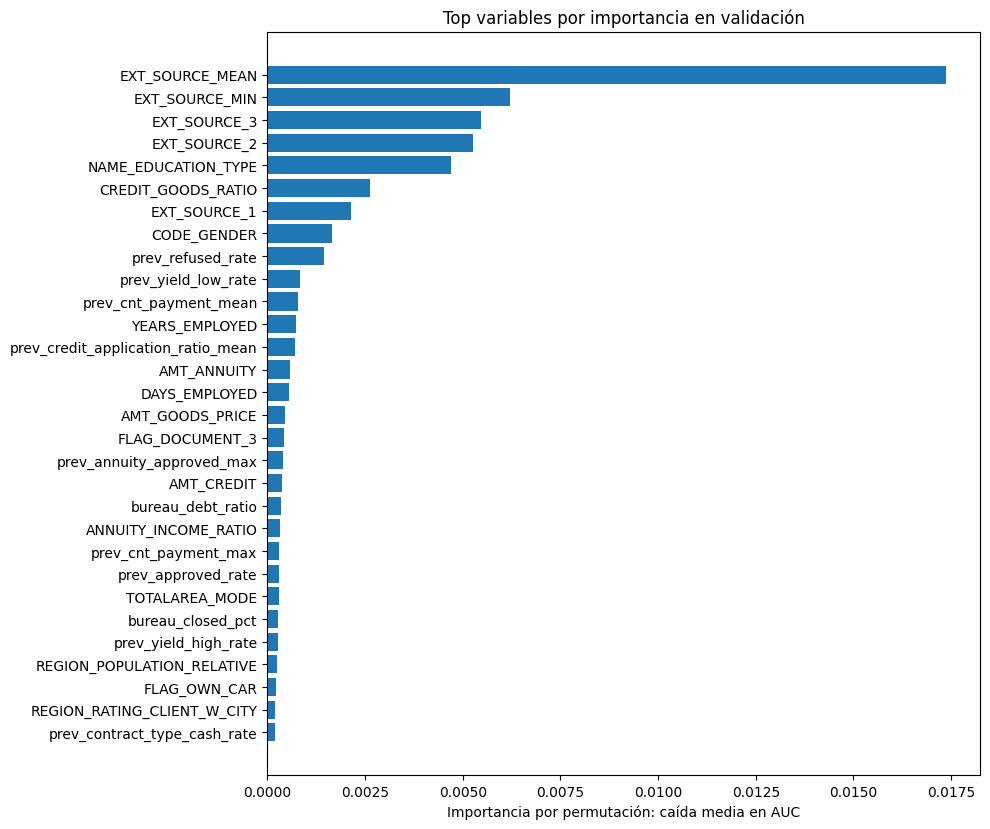

In [20]:
plot_perm = perm_report.head(30).copy()

plt.figure(figsize=(10, max(4, len(plot_perm) * 0.28)))
plt.barh(plot_perm["column"][::-1], plot_perm["perm_importance_mean"][::-1])
plt.xlabel("Importancia por permutación: caída media en AUC")
plt.title("Top variables por importancia en validación")
plt.tight_layout()
plt.show()

## 11. Redundancia: correlación entre predictores

Si dos variables numéricas tienen correlación absoluta muy alta, normalmente aportan información duplicada. En esos casos se conserva la variable con mejor evidencia frente al target, combinando:

- correlación absoluta con `TARGET`,
- información mutua,
- importancia por permutación.

In [21]:
importance_report = profile[["column", "null_pct", "dominant_pct", "outlier_iqr_pct", "nunique"]].copy()
importance_report = importance_report.merge(
    corr_target[["column", "pearson_corr_target", "abs_pearson_corr_target", "spearman_corr_target", "abs_spearman_corr_target"]],
    on="column",
    how="left",
)
importance_report = importance_report.merge(mi_report, on="column", how="left")
importance_report = importance_report.merge(perm_report, on="column", how="left")

for col in ["abs_pearson_corr_target", "abs_spearman_corr_target", "mutual_info_target", "perm_importance_mean"]:
    importance_report[col] = importance_report[col].fillna(0)

importance_report["combined_score"] = (
    importance_report["abs_pearson_corr_target"].rank(pct=True)
    + importance_report["abs_spearman_corr_target"].rank(pct=True)
    + importance_report["mutual_info_target"].rank(pct=True)
    + importance_report["perm_importance_mean"].rank(pct=True)
)

importance_report = importance_report.sort_values("combined_score", ascending=False)
importance_report.to_csv(REPORTS_DIR / "06_combined_feature_importance.csv", index=False)
display(importance_report.head(50))

,column,null_pct,dominant_pct,outlier_iqr_pct,nunique,pearson_corr_target,abs_pearson_corr_target,spearman_corr_target,abs_spearman_corr_target,mutual_info_target,perm_importance_mean,perm_importance_std,combined_score
132,EXT_SOURCE_MEAN,0.0,0.000559,0.008608,300239,-0.218985,0.218985,-0.204739,0.204739,0.023599,1.737082e-02,0.002221,3.970803
99,EXT_SOURCE_MIN,0.0,0.228229,0.000000,109536,-0.192573,0.192573,-0.181129,0.181129,0.021553,6.204027e-03,0.001375,3.934307
101,EXT_SOURCE_3,0.0,0.200809,0.014026,814,-0.155691,0.155691,-0.141933,0.141933,0.014663,5.466693e-03,0.001034,3.810219
63,EXT_SOURCE_1,0.0,0.563817,0.000000,114584,-0.097954,0.097954,-0.085904,0.085904,0.018225,2.138996e-03,0.000411,3.795620
131,EXT_SOURCE_2,0.0,0.002345,0.000000,119831,-0.159091,0.159091,-0.146321,0.146321,0.011933,5.260035e-03,0.001094,3.795620
88,CREDIT_GOODS_RATIO,0.0,0.351913,0.009678,3071,0.069665,0.069665,0.065454,0.065454,0.012105,2.630060e-03,0.000208,3.642336
103,YEARS_EMPLOYED,0.0,0.180260,0.075275,12573,-0.064200,0.064200,-0.074764,0.074764,0.005246,7.277652e-04,0.000257,3.543796
96,bureau_closed_pct,0.0,0.251523,0.000000,304,-0.076033,0.076033,-0.077322,0.077322,0.007254,2.692096e-04,0.000316,3.532847
104,DAYS_EMPLOYED,0.0,0.180260,0.075275,12573,0.064200,0.064200,0.074764,0.074764,0.005205,5.639448e-04,0.000415,3.507299
51,prev_refused_rate,0.0,0.678707,0.083353,393,0.078679,0.078679,0.068932,0.068932,0.002969,1.438324e-03,0.000228,3.489051


In [22]:
def choose_feature_to_drop(col_a, col_b, score_map):
    """Entre dos columnas altamente correlacionadas, elimina la de menor score combinado."""
    score_a = score_map.get(col_a, 0)
    score_b = score_map.get(col_b, 0)
    return col_a if score_a < score_b else col_b

candidate_cols = [c for c in X_train_clean.columns if c in importance_report["column"].values]
score_map = dict(zip(importance_report["column"], importance_report["combined_score"]))

numeric_candidate_cols = [c for c in candidate_cols if c in numeric_features]
base_keep_signal = importance_report.set_index("column").loc[numeric_candidate_cols]
numeric_for_corr = base_keep_signal[
    (base_keep_signal["abs_pearson_corr_target"] >= CORR_WITH_TARGET_MIN)
    | (base_keep_signal["mutual_info_target"] >= MI_MIN)
    | (base_keep_signal["perm_importance_mean"] > PERM_IMPORTANCE_MIN)
].index.tolist()

corr_drop_cols = set()
high_corr_pairs = []

if len(numeric_for_corr) >= 2:
    corr_matrix = X_train_clean[numeric_for_corr].corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    for col_b in upper.columns:
        correlated_a = upper.index[upper[col_b] >= PREDICTOR_CORR_THRESHOLD].tolist()
        for col_a in correlated_a:
            drop_col = choose_feature_to_drop(col_a, col_b, score_map)
            keep_col = col_b if drop_col == col_a else col_a
            corr_drop_cols.add(drop_col)
            high_corr_pairs.append({
                "feature_a": col_a,
                "feature_b": col_b,
                "abs_corr": upper.loc[col_a, col_b],
                "dropped": drop_col,
                "kept": keep_col,
            })

corr_pairs_report = pd.DataFrame(high_corr_pairs).sort_values("abs_corr", ascending=False) if high_corr_pairs else pd.DataFrame()
corr_pairs_report.to_csv(REPORTS_DIR / "07_highly_correlated_pairs.csv", index=False)

print(f"Pares con correlación >= {PREDICTOR_CORR_THRESHOLD}: {len(high_corr_pairs):,}")
print(f"Columnas a eliminar por redundancia: {len(corr_drop_cols):,}")
display(corr_pairs_report.head(50))

Pares con correlación >= 0.9: 39
Columnas a eliminar por redundancia: 18


,feature_a,feature_b,abs_corr,dropped,kept
32,DAYS_EMPLOYED,YEARS_EMPLOYED,1.000000,DAYS_EMPLOYED,YEARS_EMPLOYED
31,FLAG_EMP_PHONE,DAYS_EMPLOYED_FLAG,0.999848,FLAG_EMP_PHONE,DAYS_EMPLOYED_FLAG
0,AMT_CREDIT,AMT_GOODS_PRICE,0.986260,AMT_CREDIT,AMT_GOODS_PRICE
37,prev_application_mean,prev_goods_price_mean,0.985805,prev_goods_price_mean,prev_application_mean
38,prev_application_max,prev_goods_price_max,0.981499,prev_application_max,prev_goods_price_max
26,YEARS_BEGINEXPLUATATION_AVG,TOTALAREA_MODE,0.980418,YEARS_BEGINEXPLUATATION_AVG,TOTALAREA_MODE
10,ENTRANCES_AVG,FLOORSMAX_AVG,0.971541,ENTRANCES_AVG,FLOORSMAX_AVG
24,LIVINGAPARTMENTS_AVG,NONLIVINGAPARTMENTS_AVG,0.967531,NONLIVINGAPARTMENTS_AVG,LIVINGAPARTMENTS_AVG
7,APARTMENTS_AVG,FLOORSMAX_AVG,0.964709,FLOORSMAX_AVG,APARTMENTS_AVG
29,FLOORSMAX_AVG,TOTALAREA_MODE,0.963795,FLOORSMAX_AVG,TOTALAREA_MODE


## 12. Selección final de columnas importantes

Una columna se conserva si supera al menos una de estas señales:

- correlación absoluta con `TARGET` suficiente,
- información mutua positiva,
- importancia por permutación positiva,
- o es una variable categórica que no fue eliminada por calidad, porque puede aportar señal tras codificación.

Luego se eliminan variables redundantes por alta correlación entre predictores.

In [23]:
remaining_cols_after_quality = [c for c in X_train_clean.columns if c not in quality_drop_cols]
importance_lookup = importance_report.set_index("column")

selected_features = []
selection_rows = []

for col in remaining_cols_after_quality:
    if col not in importance_lookup.index:
        continue

    row = importance_lookup.loc[col]
    is_categorical = col in categorical_features
    has_target_signal = (
        row["abs_pearson_corr_target"] >= CORR_WITH_TARGET_MIN
        or row["abs_spearman_corr_target"] >= CORR_WITH_TARGET_MIN
        or row["mutual_info_target"] >= MI_MIN
        or row["perm_importance_mean"] > PERM_IMPORTANCE_MIN
    )

    keep = bool(has_target_signal or is_categorical)
    reason = []
    if row["abs_pearson_corr_target"] >= CORR_WITH_TARGET_MIN:
        reason.append("correlación Pearson con TARGET")
    if row["abs_spearman_corr_target"] >= CORR_WITH_TARGET_MIN:
        reason.append("correlación Spearman con TARGET")
    if row["mutual_info_target"] >= MI_MIN:
        reason.append("información mutua")
    if row["perm_importance_mean"] > PERM_IMPORTANCE_MIN:
        reason.append("importancia por permutación")
    if is_categorical and not reason:
        reason.append("categórica no descartada por calidad")

    if col in corr_drop_cols:
        keep = False
        reason.append("eliminada por alta correlación con otra variable más fuerte")

    if keep:
        selected_features.append(col)

    selection_rows.append({
        "column": col,
        "selected": keep,
        "reason": "; ".join(reason) if reason else "sin señal suficiente frente al target",
        "abs_pearson_corr_target": row["abs_pearson_corr_target"],
        "abs_spearman_corr_target": row["abs_spearman_corr_target"],
        "mutual_info_target": row["mutual_info_target"],
        "perm_importance_mean": row["perm_importance_mean"],
        "combined_score": row["combined_score"],
    })

selection_report = pd.DataFrame(selection_rows).sort_values(
    ["selected", "combined_score"], ascending=[False, False]
)
selection_report.to_csv(REPORTS_DIR / "08_final_feature_selection_report.csv", index=False)

print(f"Features candidatas después de limpieza básica: {len(remaining_cols_after_quality):,}")
print(f"Features seleccionadas finales: {len(selected_features):,}")
print(f"Features descartadas finales: {len(remaining_cols_after_quality) - len(selected_features):,}")

display(selection_report.head(80))
print("Reporte guardado en:", REPORTS_DIR / "08_final_feature_selection_report.csv")

Features candidatas después de limpieza básica: 107
Features seleccionadas finales: 89
Features descartadas finales: 18


,column,selected,reason,abs_pearson_corr_target,abs_spearman_corr_target,mutual_info_target,perm_importance_mean,combined_score
65,EXT_SOURCE_MEAN,True,correlación Pearson con TARGET; correlación Sp...,0.218985,0.204739,0.023599,1.737082e-02,3.970803
66,EXT_SOURCE_MIN,True,correlación Pearson con TARGET; correlación Sp...,0.192573,0.181129,0.021553,6.204027e-03,3.934307
31,EXT_SOURCE_3,True,correlación Pearson con TARGET; correlación Sp...,0.155691,0.141933,0.014663,5.466693e-03,3.810219
29,EXT_SOURCE_1,True,correlación Pearson con TARGET; correlación Sp...,0.097954,0.085904,0.018225,2.138996e-03,3.795620
30,EXT_SOURCE_2,True,correlación Pearson con TARGET; correlación Sp...,0.159091,0.146321,0.011933,5.260035e-03,3.795620
63,CREDIT_GOODS_RATIO,True,correlación Pearson con TARGET; correlación Sp...,0.069665,0.065454,0.012105,2.630060e-03,3.642336
60,YEARS_EMPLOYED,True,correlación Pearson con TARGET; correlación Sp...,0.064200,0.074764,0.005246,7.277652e-04,3.543796
79,bureau_closed_pct,True,correlación Pearson con TARGET; correlación Sp...,0.076033,0.077322,0.007254,2.692096e-04,3.532847
87,prev_refused_rate,True,correlación Pearson con TARGET; correlación Sp...,0.078679,0.068932,0.002969,1.438324e-03,3.489051
104,prev_yield_low_rate,True,correlación Pearson con TARGET; correlación Sp...,0.050528,0.053755,0.003701,8.431728e-04,3.401460


Reporte guardado en: /workspaces/Proyecto_Integrador/data/feature_selection_reports/08_final_feature_selection_report.csv


## 13. Dataset final para entrenamiento

Se construye el dataset final con:

- `SK_ID_CURR`, para trazabilidad.
- `TARGET`, para entrenamiento supervisado.
- Solo las columnas seleccionadas.

También se guarda un archivo de texto con la lista de variables finales.

In [24]:
final_train_selected = df[[ID_COL, TARGET_COL] + selected_features].copy()
final_train_selected = final_train_selected.replace([np.inf, -np.inf], np.nan)

assert final_train_selected[ID_COL].is_unique, "SK_ID_CURR no es único en el dataset final."
assert final_train_selected[TARGET_COL].notna().all(), "TARGET contiene nulos."
assert final_train_selected.shape[0] == df.shape[0], "Se perdieron filas durante la selección."

final_train_selected.to_parquet(SELECTED_DATASET_PATH, index=False)

selected_features_path = REPORTS_DIR / "selected_features.txt"
selected_features_path.write_text("".join(selected_features), encoding="utf-8")

print("Dataset final seleccionado")
print(f"Filas: {final_train_selected.shape[0]:,}")
print(f"Columnas totales incluyendo ID y TARGET: {final_train_selected.shape[1]:,}")
print(f"Features para entrenamiento: {len(selected_features):,}")
print(f"Guardado en: {SELECTED_DATASET_PATH}")
print(f"Lista de features guardada en: {selected_features_path}")

display(final_train_selected.head())

Dataset final seleccionado
Filas: 307,511
Columnas totales incluyendo ID y TARGET: 91
Features para entrenamiento: 89
Guardado en: /workspaces/Proyecto_Integrador/data/train_selected_features_2.parquet
Lista de features guardada en: /workspaces/Proyecto_Integrador/data/feature_selection_reports/selected_features.txt


,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_WORK_PHONE,FLAG_PHONE,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,BASEMENTAREA_AVG,COMMONAREA_AVG,LANDAREA_AVG,NONLIVINGAREA_AVG,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_3,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,DAYS_EMPLOYED_FLAG,AGE_YEARS,YEARS_EMPLOYED,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_GOODS_RATIO,INCOME_PER_PERSON,EXT_SOURCE_MEAN,EXT_SOURCE_MIN,BUREAU_QUERIES_TOTAL,bureau_n_credits,bureau_n_active,bureau_avg_days_credit,bureau_min_days_credit,bureau_avg_days_update,bureau_total_credit,bureau_total_debt,bureau_n_card,bureau_active_pct,bureau_closed_pct,bureau_debt_ratio,bureau_mean_credit_duration,bureau_mean_days_overrun,bureau_pct_paid_early,no_bureau_history,prev_app_count,prev_approved_rate,prev_refused_rate,prev_canceled_rate,prev_contract_type_cash_rate,prev_contract_type_consumer_rate,prev_contract_type_revolving_rate,prev_annuity_approved_mean,prev_annuity_approved_max,prev_application_mean,prev_credit_approved_mean,prev_credit_application_ratio_mean,prev_goods_price_max,prev_cnt_payment_mean,prev_cnt_payment_max,prev_reject_hc_rate,prev_yield_high_rate,prev_yield_low_rate,prev_insured_on_approval_rate,prev_insured_on_approval_count
0,100002,1,M,N,Y,0,202500.0,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-3648.0,-2120,0.0,0,1,Laborers,1.0,2,WEDNESDAY,10,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0369,0.0143,0.0369,0.0000,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,-1134.0,1,0.0,0.0,0,25.902806,1.744011,2.007889,0.121978,1.158397,202500.0,0.161787,0.083037,1.0,8.0,2.0,-874.00,-1437.0,-499.875,865055.565,245781.0,4.0,0.25,0.75,0.284121,277.000000,-163.5,0.166667,0,1.0,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,9251.775,9251.775,179055.00,179055.00,1.000000,179055.0,24.000000,24.0,0.0,0.000000,1.000000,0.000000,0.0
1,100003,0,F,N,N,0,270000.0,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-1186.0,-291,0.0,0,1,Core staff,2.0,1,MONDAY,11,0,0,School,0.311267,0.622246,0.535276,0.0529,0.0605,0.0130,0.0098,reg oper account,block of flats,0.0714,Block,No,0.0,1.0,-828.0,1,0.0,0.0,0,45.900068,3.252567,4.790750,0.132217,1.145199,135000.0,0.489596,0.311267,0.0,4.0,1.0,-1400.75,-2586.0,-816.000,1017400.500,0.0,2.0,0.25,0.75,0.000000,568.333333,34.0,0.333333,0,3.0,1.000000,0.000000,0.000000,0.333333,0.666667,0.000000,56553.990,98356.995,435436.50,484191.00,1.057664,900000.0,10.000000,12.0,0.0,0.000000,0.333333,0.666667,2.0
2,100004,0,M,Y,Y,0,67500.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-4260.0,-2531,26.0,1,1,Laborers,1.0,2,MONDAY,9,0,0,Government,0.505998,0.555912,0.729567,-1.0000,-1.0000,-1.0000,-1.0000,Unknown,Unknown,-1.0000,Unknown,Unknown,0.0,0.0,-815.0,0,0.0,0.0,0,52.145106,0.616016,2.000000,0.100000,1.000000,67500.0,0.597159,0.505998,0.0,2.0,0.0,-867.00,-1326.0,-532.000,189037.800,0.0,0.0,0.00,1.00,0.000000,334.500000,-44.0,0.000000,0,1.0,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,5357.250,5357.250,24282.00,20106.00,0.828021,24282.0,4.000000,4.0,0.0,0.000000,0.000000,0.000000,0.0
3,100006,0,F,N,Y,0,135000.0,29686.5,297000.0,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.008019,-9833.0,-2437,0.0,0,0,Laborers,2.0,2,WEDNESDAY,17,0,0,Busi

## 14. Pipeline recomendado para entrenar con las columnas seleccionadas

Este bloque deja preparado un preprocesador reutilizable. La imputación y codificación deben hacerse dentro del pipeline para evitar leakage cuando hagas validación cruzada o entrenamiento final.

In [25]:
X_selected = final_train_selected[selected_features]
y_selected = final_train_selected[TARGET_COL].astype(int)

selected_numeric_features = X_selected.select_dtypes(include=[np.number, "bool"]).columns.tolist()
selected_categorical_features = [c for c in X_selected.columns if c not in selected_numeric_features]

try:
    selected_ohe = OneHotEncoder(handle_unknown="ignore", min_frequency=0.01, sparse_output=False)
except TypeError:
    selected_ohe = OneHotEncoder(handle_unknown="ignore", min_frequency=0.01, sparse=False)

selected_preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), selected_numeric_features),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
            ("onehot", selected_ohe),
        ]), selected_categorical_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

print(f"Numéricas seleccionadas: {len(selected_numeric_features):,}")
print(f"Categóricas seleccionadas: {len(selected_categorical_features):,}")
print("Preprocesador listo para conectarse con el modelo final.")

Numéricas seleccionadas: 74
Categóricas seleccionadas: 15
Preprocesador listo para conectarse con el modelo final.


## 15. Resumen ejecutivo de decisiones

Al finalizar la ejecución, revisa estos archivos en `data/feature_selection_reports/`:

| Reporte | Qué contiene |
|---|---|
| `01_column_profile_raw.csv` | Perfil completo por columna: nulos, cardinalidad, outliers, correlación inicial |
| `02_basic_cleaning_decisions.csv` | Columnas eliminadas por reglas básicas y justificación |
| `03_numeric_correlation_with_target.csv` | Correlaciones numéricas contra `TARGET` |
| `04_mutual_information_with_target.csv` | Información mutua contra `TARGET` |
| `05_permutation_importance.csv` | Importancia por permutación usando AUC |
| `06_combined_feature_importance.csv` | Score combinado de importancia |
| `07_highly_correlated_pairs.csv` | Pares redundantes con alta correlación |
| `08_final_feature_selection_report.csv` | Decisión final columna por columna |
| `selected_features.txt` | Lista definitiva de columnas para entrenamiento |

La salida principal es:

`data/train_selected_features.parquet`

Ese archivo conserva una fila por `SK_ID_CURR` y contiene únicamente las variables recomendadas para entrenar el modelo.